In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path
import pytensor
from tqdm import tqdm
import xarray as xr
import warnings
import seaborn as sns

warnings.filterwarnings("ignore")  # az.compare will throw warnings
plt.rcParams["figure.constrained_layout.use"] = True

## Model comparison

In [5]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
participants_list = hrd_df.participant_id.unique()

In [7]:
missing_participants = []
model_comparison_df = pd.DataFrame([])

loo = {
    "standard": [],
    "cardiac_beliefs": [],
    "weigthed_update": [],
    "cardiac_hgf": [],
}

for participant_id in tqdm(participants_list[:10]):
    for session in [1, 2]:
        standard_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"standard_model_session{session}_{participant_id}.nc"
        )

        weighted_update_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"weighted_update_session{session}_{participant_id}.nc"
        )

        cardiac_believing_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"cardiac_believing_session{session}_{participant_id}.nc"
        )

        cardiac_hgf_path = (
            Path().cwd().parent.parent
            / "results"
            / "idata"
            / f"cardiac_hgf_session{session}_{participant_id}.nc"
        )

        if (
            standard_path.exists()
            & weighted_update_path.exists()
            & cardiac_believing_path.exists()
            & cardiac_hgf_path.exists()
        ):
            standard_idata = az.from_netcdf(standard_path)
            cardiac_believing_idata = az.from_netcdf(cardiac_believing_path)
            weighted_update_idata = az.from_netcdf(weighted_update_path)
            cardiac_hgf_idata = az.from_netcdf(cardiac_hgf_path)

            model_compare = az.compare(
                {
                    "standard": standard_idata,
                    "cardiac_beliefs": cardiac_believing_idata,
                    "weigthed_update": weighted_update_idata,
                    "cardiac_hgf": cardiac_hgf_idata,
                },
            )
            model_compare["participant_id"] = participant_id
            model_compare["session"] = session
            model_comparison_df = pd.concat([model_comparison_df, model_compare])

            loo["standard"].append(az.loo(standard_idata).loo_i)
            loo["weigthed_update"].append(az.loo(wweighted_update_idata).loo_i)

        else:
            missing_participants.append((participant_id, session))

 20%|██████████████████████████████████████████████▌                                                                                                                                                                                          | 2/10 [00:00<00:00, 423.30it/s]


OSError: Unable to synchronously open file (file signature not found)

In [146]:
model_comparison_df["model"] = pd.Categorical(
    model_comparison_df.index,
    categories=["standard", "cardiac_beliefs", "cardiac_hgf", "weigthed_update"],
    ordered=True,
)

In [155]:
this_df

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale,participant_id,session,model
weigthed_update,0,-29.787820,3.645855,0.0,1.000000,5.639152,0.0,True,log,sub-0022,2,weigthed_update
weigthed_update,0,-33.897201,3.607812,0.0,0.730347,6.168009,0.0,True,log,sub-0023,2,weigthed_update
weigthed_update,0,-45.061007,3.634745,0.0,0.810757,5.864807,0.0,True,log,sub-0025,2,weigthed_update
cardiac_hgf,0,-44.628758,3.860876,0.0,0.584396,6.777251,0.0,True,log,sub-0027,2,cardiac_hgf
weigthed_update,0,-40.178676,3.380806,0.0,0.714707,6.034740,0.0,True,log,sub-0028,2,weigthed_update
...,...,...,...,...,...,...,...,...,...,...,...,...
cardiac_hgf,0,-39.708974,3.029314,0.0,0.670728,6.433305,0.0,True,log,sub-0626,2,cardiac_hgf
weigthed_update,0,-46.179105,3.687020,0.0,0.816407,6.134439,0.0,False,log,sub-0628,2,weigthed_update
weigthed_update,0,-46.100036,3.958283,0.0,0.443266,6.326981,0.0,False,log,sub-0631,2,weigthed_update
standard,0,-61.842937,3.310018,0.0,1.000000,5.617419,0.0,False,log,sub-0638,2,standard


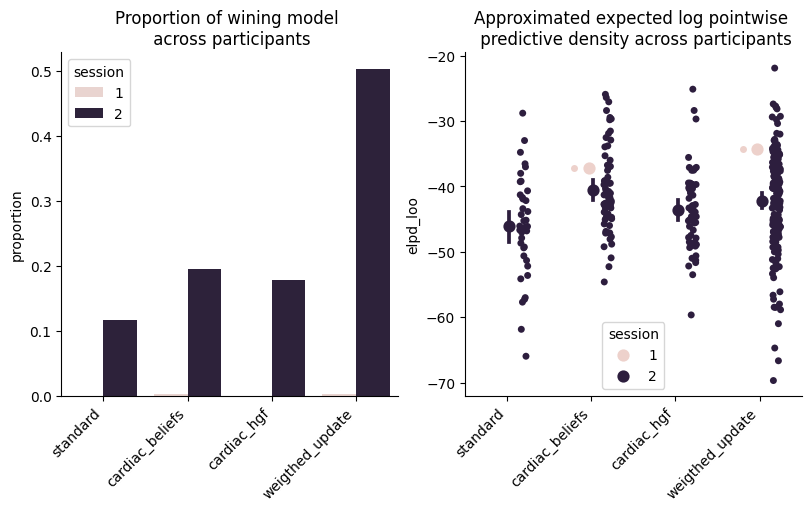

In [154]:
_, axs = plt.subplots(figsize=(8, 5), ncols=2)

this_df = model_comparison_df[model_comparison_df["rank"] == 0]
sns.countplot(this_df, x="model", hue="session", stat="proportion", ax=axs[0])
axs[0].set_xticklabels(
    ["standard", "cardiac_beliefs", "cardiac_hgf", "weigthed_update"],
    rotation=45,
    ha="right",  # Horizontal alignment
    fontsize=10,  # Font size
)
axs[0].set(title="Proportion of wining model \n across participants", xlabel=None)

sns.stripplot(
    this_df, x="model", y="elpd_loo", hue="session", dodge=True, ax=axs[1], legend=None
)
sns.pointplot(
    this_df,
    x="model",
    y="elpd_loo",
    hue="session",
    dodge=True,
    linestyle="none",
    ax=axs[1],
)
axs[1].set_xticklabels(
    ["Psychometric function", "Cardiac beliefs", "Cardiac HGF", "Weighted updates"],
    rotation=45,
    ha="right",  # Horizontal alignment
    fontsize=10,  # Font size
)
axs[1].set(
    title="Approximated expected log pointwise \n predictive density across participants",
    xlabel=None,
)

sns.despine()

In [79]:
log_liks = [idata.log_likelihood for idata in combined_standard_model]
aligned_log_liks = xr.align(*log_liks, join="outer", fill_value=np.nan)

log_likelihood_combined = xr.concat(aligned_log_liks, dim="participant").assign_coords(
    participant=participants
)

In [71]:
def combine_idata(idata_list, participants_list):
    log_liks = [idata.log_likelihood for idata in idata_list]
    aligned_log_liks = xr.align(*log_liks, join="outer", fill_value=np.nan)

    log_likelihood_combined = xr.concat(
        aligned_log_liks, dim="participant"
    ).assign_coords(participant=participants_list)

    posteriors = [idata.posterior for idata in idata_list]
    aligned_posteriors = xr.align(*posteriors, join="outer", fill_value=np.nan)

    posterior_combined = xr.concat(aligned_posteriors, dim="participant").assign_coords(
        participant=participants_list
    )

    return az.InferenceData(
        posterior=posterior_combined,
        log_likelihood=log_likelihood_combined,
    )

In [72]:
standard_idata = combine_idata(combined_standard_model, participants)
cardiac_belief_idata = combine_idata(combined_cardiac_believing, participants)
weighted_update_idata = combine_idata(combined_weighted_update, participants)
cardiac_hgf_idata = combine_idata(combined_cardiac_hgf, participants)

/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/work/git/Computationa

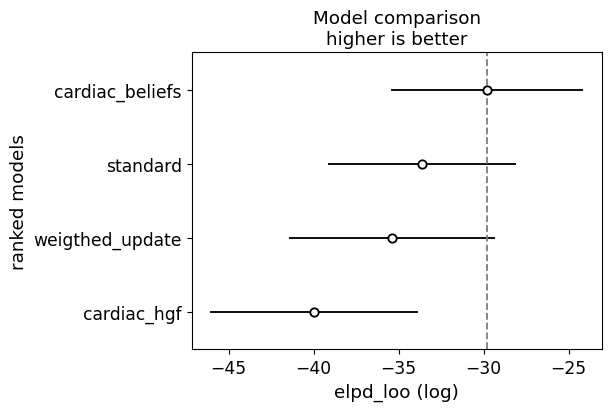

In [73]:
nsub = 0
model_compare = az.compare(
    {
        "standard": combined_standard_model[nsub],
        "cardiac_beliefs": combined_cardiac_believing[nsub],
        "weigthed_update": combined_weighted_update[nsub],
        "cardiac_hgf": combined_cardiac_hgf[nsub],
    },
)
az.plot_compare(model_compare);

In [74]:
model_compare = az.compare(
    {
        "standard": standard_idata,
        "cardiac_beliefs": cardiac_belief_idata,
        "weigthed_update": weighted_update_idata,
        "cardiac_hgf": cardiac_hgf_idata,
    },
);

/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/work/git/Computationa

In [160]:
all_pointwise = az.loo(az.from_netcdf(standard_path)).loo_i

elpd_total = all_pointwise.sum()
se_total = np.sqrt(len(all_pointwise) * np.var(all_pointwise, ddof=1))

In [161]:
elpd_total

<xarray.DataArray 'loo_i' ()> Size: 8B
array(-44.5957633)

In [162]:
se_total

<xarray.DataArray 'loo_i' ()> Size: 8B
array(6.32230554)